# Dataset loader check: `grade_dataset.py` + model forward pass

Grade1 vs pooled Grade2-6, `motion_grades_chunk_5_dataset_hfiltered`. Same pipeline as `train.py --use_grade_dataset`: dataset -> batch -> ROI extraction -> model -> losses.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root, so grade_dataset/atlas_fc/models/losses import

import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from grade_dataset import FMRIUnpairedGradeDataset, worker_init_fn, GRADE_A, GRADES_B_ALL
from atlas_fc import load_age_atlases_cropped, PADDED_SPATIAL, age_group_for_subject
from models.st_model import SpatioTemporalCycleGAN
from losses import generator_loss, LossWeights
from models.roi_discriminator import MultiScaleROITemporalDiscriminator
from losses import temporal_discriminator_loss, temporal_generator_loss, roi_cycle_consistency_loss

torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


## 1. Dataset sizes

In [2]:
train_ds = FMRIUnpairedGradeDataset(split="train", full_coverage=False)
val_ds   = FMRIUnpairedGradeDataset(split="val",   full_coverage=True)

print(f"train: A ({GRADE_A})={train_ds.A_size}  B (pooled {GRADES_B_ALL})={train_ds.B_size}  "
      f"epoch_len={len(train_ds)}")
print(f"val  : A={val_ds.A_size}  B={val_ds.B_size}  epoch_len={len(val_ds)} (full_coverage)")

train: A (Grade 1)=9350  B (pooled ('Grade 2', 'Grade 3', 'Grade 4', 'Grade 5', 'Grade 6'))=13033  epoch_len=9350
val  : A=1724  B=3012  epoch_len=3012 (full_coverage)


## 2. One real batch

In [ ]:
BATCH_SIZE = 2
train_ds.set_epoch(0)  # required before creating the DataLoader iterator -- see set_epoch()'s docstring
loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, worker_init_fn=worker_init_fn,
)

batch = next(iter(loader))
x_a, x_b = batch["A"], batch["B"]
print("A shape:", tuple(x_a.shape), " B shape:", tuple(x_b.shape))
print("A subjects/ages:", list(zip(batch["A_meta"]["subject_id"], batch["A_meta"]["age_group"])))
print("B subjects/ages:", list(zip(batch["B_meta"]["subject_id"], batch["B_meta"]["age_group"])))
print("A grades:", batch["A_meta"]["grade"], " A mean FD:", [round(v, 4) for v in batch["A_meta"]["chunk_mean_fd"].tolist()])
print("B grades:", batch["B_meta"]["grade"], " B mean FD:", [round(v, 4) for v in batch["B_meta"]["chunk_mean_fd"].tolist()])

A shape: (2, 5, 64, 72, 56)  B shape: (2, 5, 64, 72, 56)
A subjects/ages: [('IRC13', '2mo'), ('ICN8', '2mo')]
B subjects/ages: [('ICC225', '2mo'), ('IRC109', '2mo')]
A grades: ['Grade 1', 'Grade 1']  A mean FD: [0.1031, 0.0687]
B grades: ['Grade 5', 'Grade 2']  B mean FD: [2.2683, 0.3427]


## 3. A vs B sample

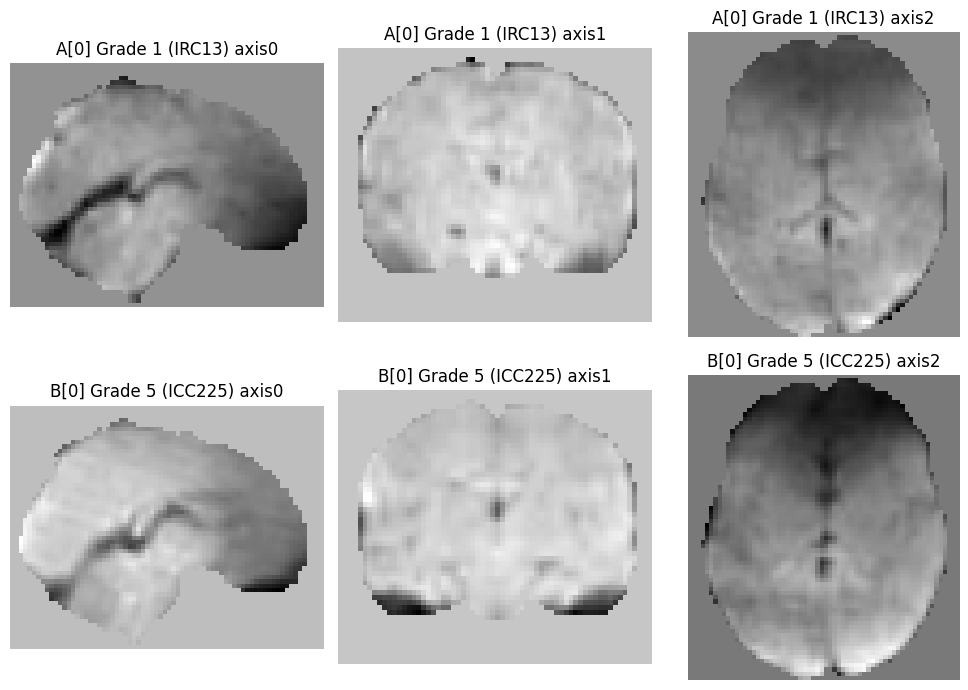

In [4]:
def show_chunk(ax_row, tensor, title):
    """tensor: (T, H, W, D) -- mean over T, 3 mid-slices."""
    mean_vol = tensor.mean(dim=0).numpy()  # (H, W, D)
    H, W, D = mean_vol.shape
    ax_row[0].imshow(mean_vol[H // 2, :, :].T, cmap="gray", origin="lower"); ax_row[0].set_title(f"{title} axis0")
    ax_row[1].imshow(mean_vol[:, W // 2, :].T, cmap="gray", origin="lower"); ax_row[1].set_title(f"{title} axis1")
    ax_row[2].imshow(mean_vol[:, :, D // 2].T, cmap="gray", origin="lower"); ax_row[2].set_title(f"{title} axis2")
    for a in ax_row:
        a.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
show_chunk(axes[0], x_a[0], f"A[0] {batch['A_meta']['grade'][0]} ({batch['A_meta']['subject_id'][0]})")
show_chunk(axes[1], x_b[0], f"B[0] {batch['B_meta']['grade'][0]} ({batch['B_meta']['subject_id'][0]})")
plt.tight_layout()
plt.show()

## 4. ROI extraction (SchaeferAtlasCropped)

In [5]:
atlases = load_age_atlases_cropped()
print({age: (atlas.n_rois, atlas.target_spatial) for age, atlas in atlases.items()})

def extract_roi_ts_batch(volumes, ages, atlases):
    """volumes: (B,T,H,W,D). ages: list of 'age_group' strings. -> (B, n_rois, T)"""
    out = []
    for b, age in enumerate(ages):
        out.append(atlases[age].extract_roi_timeseries(volumes[b]))  # (T, n_rois)
    return torch.stack(out, dim=0).permute(0, 2, 1)  # (B, n_rois, T)

roi_ts_a = extract_roi_ts_batch(x_a, batch["A_meta"]["age_group"], atlases)
roi_ts_b = extract_roi_ts_batch(x_b, batch["B_meta"]["age_group"], atlases)
print("ROI timeseries A:", tuple(roi_ts_a.shape), " B:", tuple(roi_ts_b.shape))

{'2mo': (400, (64, 72, 56)), '9mo': (400, (64, 72, 56))}
ROI timeseries A: (2, 400, 5)  B: (2, 400, 5)


## 5. Model forward pass (SpatioTemporalCycleGAN)

In [6]:
model = SpatioTemporalCycleGAN(
    in_timepoints=5, spatial_dims=PADDED_SPATIAL, residual=True,
).to(DEVICE)
print(f"model params: {sum(p.numel() for p in model.parameters()):,}")

x_a_dev, x_b_dev = x_a.to(DEVICE), x_b.to(DEVICE)
out = model(x_a_dev, x_b_dev, detach_fakes_for_D=False)

print("x_hat_b (A->B corrected)  :", tuple(out.x_hat_b.shape))
print("x_hat_a (B->A corrupted)  :", tuple(out.x_hat_a.shape))
print("x_cycle_a (A->B->A)       :", tuple(out.x_cycle_a.shape))

weights = LossWeights(adv=1.0, cyc=10.0, idt=5.0)
g_losses = generator_loss(out, x_a_dev, x_b_dev, weights)
for k, v in g_losses.items():
    print(f"  {k:<8} {v.item():.4f}")

model params: 165,548,806


x_hat_b (A->B corrected)  : (2, 5, 64, 72, 56)
x_hat_a (B->A corrupted)  : (2, 5, 64, 72, 56)
x_cycle_a (A->B->A)       : (2, 5, 64, 72, 56)
  adv      1.2667
  cyc      0.8021
  idt      0.6105
  total    12.3397


## 6. ROI-timeseries losses (cycle, discriminator, generator)

In [7]:
roi_disc = MultiScaleROITemporalDiscriminator(n_rois=atlases["2mo"].n_rois).to(DEVICE)

# Cycle-consistency: ROI-ts of x_a vs ROI-ts of the A->B->A reconstruction
roi_ts_input = extract_roi_ts_batch(x_a_dev.cpu(), batch["A_meta"]["age_group"], atlases).to(DEVICE)
roi_ts_cycle = extract_roi_ts_batch(out.x_cycle_a.detach().cpu(), batch["A_meta"]["age_group"], atlases).to(DEVICE)
L_roi_cycle = roi_cycle_consistency_loss(roi_ts_input, roi_ts_cycle)
print(f"roi_cycle_consistency_loss : {L_roi_cycle.item():.4f}")

# Adversarial: D on real B ROI-ts vs fake (corrected) ROI-ts
roi_ts_real = extract_roi_ts_batch(x_b_dev.cpu(), batch["B_meta"]["age_group"], atlases).to(DEVICE)
roi_ts_fake = extract_roi_ts_batch(out.x_hat_b.detach().cpu(), batch["A_meta"]["age_group"], atlases).to(DEVICE)

d_out_real = roi_disc(roi_ts_real)
d_out_fake = roi_disc(roi_ts_fake)
d_losses = temporal_discriminator_loss(d_out_real, d_out_fake, lambda_roi=0.5)
print(f"temporal_discriminator_loss: total={d_losses['total'].item():.4f}  "
      f"global={d_losses['global'].item():.4f}  roi={d_losses['roi'].item():.4f}")

g_out_fake = roi_disc(roi_ts_fake)
g_roi_losses = temporal_generator_loss(g_out_fake, lambda_roi=0.5)
print(f"temporal_generator_loss    : total={g_roi_losses['total'].item():.4f}  "
      f"global={g_roi_losses['global'].item():.4f}  roi={g_roi_losses['roi'].item():.4f}")

roi_cycle_consistency_loss : 0.3670


temporal_discriminator_loss: total=0.7831  global=0.5330  roi=0.5001


temporal_generator_loss    : total=1.5266  global=1.0266  roi=1.0001


## Key numbers

| | |
|---|---|
| train A / B / epoch_len | 9350 / 13033 / 9350 |
| val A / B / epoch_len (full_coverage) | 1724 / 3012 / 3012 |
| chunk shape | (5, 64, 72, 56) |
| ROI timeseries shape | (B, 400, 5) |
| model params | 165,548,806 |
| generator: adv / cyc / idt / total | 1.267 / 0.802 / 0.611 / 12.340 |
| roi_cycle_consistency_loss | 0.367 |
| temporal_discriminator_loss (total/global/roi) | 0.783 / 0.533 / 0.500 |
| temporal_generator_loss (total/global/roi) | 1.527 / 1.027 / 1.000 |